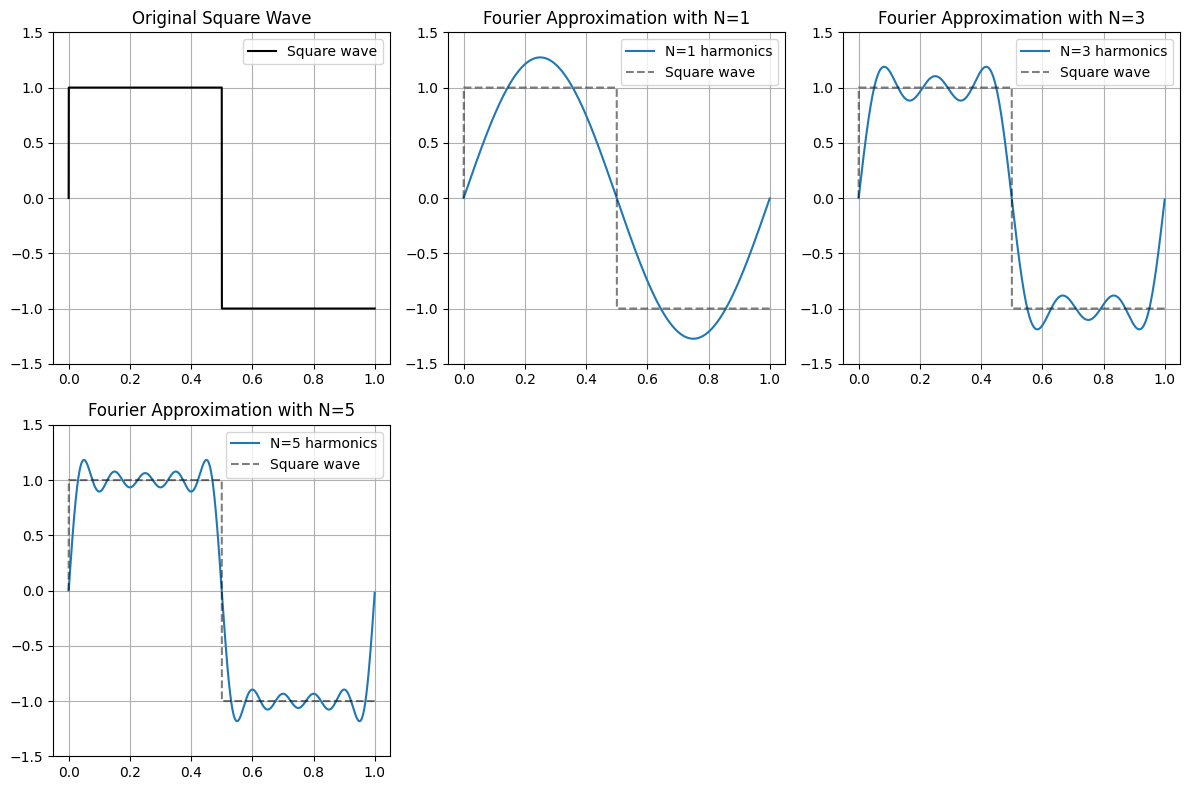

--- DFT / FFT Performance Comparison ---
Naive DFT Execution Time: 4.813774 seconds
NumPy FFT Execution Time: 0.003896 seconds
FFT is approximately 1235.72 times faster.

Our DFT implementation is close to NumPy's FFT: True


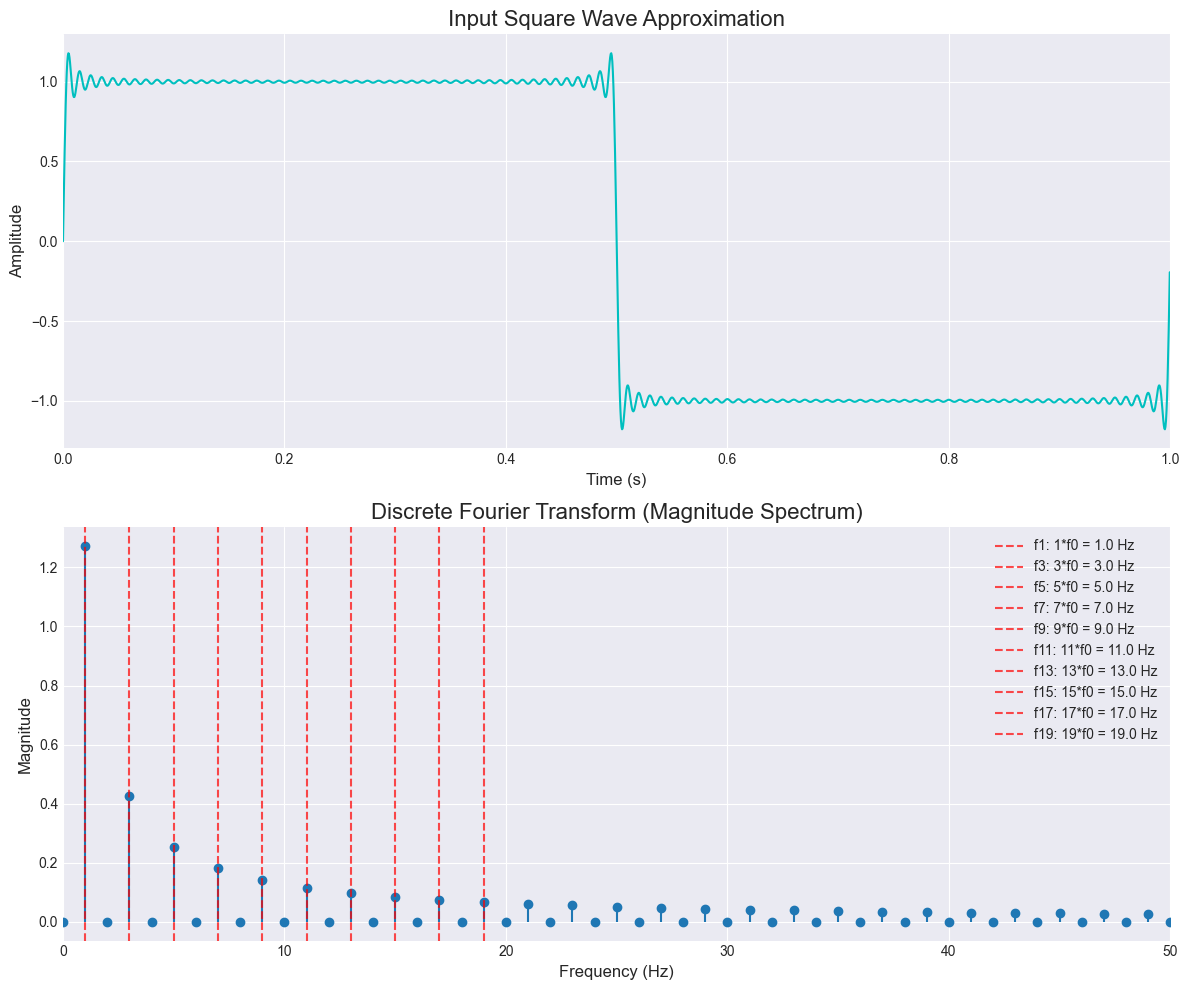

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


# Set parameters for the signal
N = 2048  # Number of sample points
T = 1.0  # Duration of the signal in seconds
f0 = 1  # Fundamental frequency of the square wave in Hz


# List of harmonic numbers used to construct the square wave
harmonics = [1, 3, 5]


# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))


# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)
    for k in range(N):

        # The Fourier series of a square wave contains only odd harmonics.
        n = 2 * k + 1

        # Add harmonics to reconstruct the square wave.
        result += np.sin(2 * np.pi * n * f0 * t) / n
    return (4 / np.pi) * result




# Create the time vector
# np.linspace generates evenly spaced numbers over a specified interval.
# We use endpoint=False because the interval is periodic.
t = np.linspace(0.0, T, N, endpoint=False)

# Generate the original square wave
square = square_wave(t)

plt.figure(figsize=(12, 8))
# Plot the original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()


# Plot Fourier reconstructions under different number of harmonics
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)
    y = square_wave_fourier(t, f0, Nh)
    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")
    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# 2. Apply the DFT and time the execution
def naive_dft(x):
    """
    Compute the Discrete Fourier Transform (DFT) of a 1D signal.

    This is a "naive" implementation that directly follows the DFT formula,
    which has a time complexity of O(N^2).

    Args:
        x (np.ndarray): The input signal, a 1D NumPy array.

    Returns:
        np.ndarray: The complex-valued DFT of the input signal.
    """
    N = len(x)
    # Create an empty array of complex numbers to store the DFT results
    X = np.zeros(N, dtype=np.complex128)

    # Iterate through each frequency bin (k)
    for k in range(N):
        # For each frequency bin, sum the contributions from all input samples (n)
        for n in range(N):
            # The core DFT formula: x[n] * e^(-2j * pi * k * n / N)
            angle = -2j * np.pi * k * n / N
            X[k] += x[n] * np.exp(angle)
    return X


# Construct a square wave using 50 harmonics
signal = square_wave_fourier(t, f0, 50)


# Time the naive DFT implementation
start_time_naive = time.time()
dft_result = naive_dft(signal)
end_time_naive = time.time()
naive_duration = end_time_naive - start_time_naive


# Time NumPy's FFT implementation
start_time_fft = time.time()
fft_result = np.fft.fft(signal)
end_time_fft = time.time()
fft_duration = end_time_fft - start_time_fft

# 3. Print Timings and Verification
print("--- DFT / FFT Performance Comparison ---")
print(f"Naive DFT Execution Time: {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time: {fft_duration:.6f} seconds")
# It's possible for the FFT to be so fast that the duration is 0.0, so we handle that
# case.
if fft_duration > 0:
    print(f"FFT is approximately {naive_duration / fft_duration:.2f} times faster.")
else:
    print("FFT was too fast to measure a significant duration difference.")

# Check if our implementation is close to NumPy's result
# np.allclose is used for comparing floating-point arrays.
print(
    f"\nOur DFT implementation is close to NumPy's FFT: "
    f"{np.allclose(dft_result, fft_result)}"
)


# 4. Prepare for Plotting
# Generate the frequency axis for the plot.
# np.fft.fftfreq returns the DFT sample frequencies.
# We only need the first half of the frequencies (the positive ones) due to symmetry.
xf = np.fft.fftfreq(N, d=T / N)[:N // 2]
# We normalize the magnitude by N and multiply by 2 to get the correct amplitude.
magnitude = 2.0 / N * np.abs(dft_result[0:N // 2])

# 5. Visualize the Results
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the original time-domain signal
ax1.plot(t, signal, color='c')

ax1.set_title('Input Square Wave Approximation', fontsize=16)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_xlim(0, 1.0)  # Show a few cycles of the sine wave
ax1.grid(True)

# Plot the frequency-domain signal (magnitude of the DFT)
ax2.stem(xf, magnitude, basefmt=" ")
ax2.set_title('Discrete Fourier Transform (Magnitude Spectrum)', fontsize=16)
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Magnitude', fontsize=12)
ax2.set_xlim(0, 50)  # Focus on lower frequencies
ax2.grid(True)


# Add vertical lines for the first ten frequencies
for i in range(20):
    if i < len(xf) and i % 2 == 1:  # Only plot odd harmonics
        ax2.axvline(
            xf[i], color='r', linestyle='--', alpha=0.7,
            label=f'f{i}: {i}*f0 = {xf[i]:.1f} Hz'
        )

# Only show labels for first 3 frequencies to avoid cluttering
ax2.legend()
plt.tight_layout()
plt.show()


In [2]:
import torch
import pandas as pd

# Prefer an NVIDIA GPU, then an Apple Silicon GPU, then CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# MPS does not support float64 / complex128, so use float32 there.
if device.type == "mps":
    real_dtype, complex_dtype = torch.float32, torch.complex64
else:
    real_dtype, complex_dtype = torch.float64, torch.complex128

def synchronize_device():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

print("PyTorch device:", device)

# PyTorch versions of the two square-wave functions required by the task.
def square_wave_torch(t, f0):
    return torch.sign(torch.sin(2.0 * torch.pi * f0 * t))

def square_wave_fourier_torch(t, f0, num_harmonics):
    result = torch.zeros_like(t)
    for k in range(num_harmonics):
        harmonic_number = 2 * k + 1
        result += torch.sin(2 * torch.pi * harmonic_number * f0 * t) / harmonic_number
    return (4 / torch.pi) * result

def naive_dft_gpu(signal):
    """Naive DFT using PyTorch tensor operations on the GPU."""
    signal = signal.to(device=device, dtype=complex_dtype)
    num_samples = signal.numel()
    n = torch.arange(num_samples, device=device, dtype=real_dtype)
    k = n.reshape(-1, 1)
    dft_matrix = torch.exp(-2j * torch.pi * k * n / num_samples)
    return dft_matrix @ signal

# Warm up GPU and FFT once. Their first call includes one-off setup overhead.
naive_dft_gpu(torch.zeros(8, device=device, dtype=real_dtype))
synchronize_device()
np.fft.fft(np.zeros(8))

# Signals are prepared before timing so that only DFT/FFT work is timed.
sizes = [128, 256, 512, 1024, 2048]
results = []

for signal_size in sizes:
    time_numpy = np.linspace(0.0, T, signal_size, endpoint=False)
    signal_numpy = square_wave_fourier(time_numpy, f0, 50)

    time_torch = torch.arange(signal_size, device=device, dtype=real_dtype) * (T / signal_size)
    _square_torch = square_wave_torch(time_torch, f0)
    signal_torch = square_wave_fourier_torch(time_torch, f0, 50)

    # 1. CPU/Python naive DFT
    start = time.perf_counter()
    naive_dft(signal_numpy)
    naive_time = time.perf_counter() - start

    # 2. GPU/PyTorch naive DFT. Synchronising makes asynchronous GPU timing accurate.
    synchronize_device()
    start = time.perf_counter()
    gpu_result = naive_dft_gpu(signal_torch)
    synchronize_device()
    gpu_time = time.perf_counter() - start

    # 3. NumPy built-in FFT
    start = time.perf_counter()
    fft_result = np.fft.fft(signal_numpy)
    fft_time = time.perf_counter() - start

    reference_result = np.fft.fft(signal_torch.cpu().numpy())
    relative_error = np.linalg.norm(gpu_result.cpu().numpy() - reference_result) / np.linalg.norm(reference_result)

    results.append({
        "N": signal_size,
        "CPU naive DFT (s)": naive_time,
        "GPU naive DFT (s)": gpu_time,
        "NumPy FFT (s)": fft_time,
        "Relative error": relative_error,
        "Tensor DFT matches FFT": relative_error < 1e-3,
    })

results_table = pd.DataFrame(results)
print(results_table)
print("On a GPU, typical order after warm-up: NumPy FFT, tensor naive DFT, CPU naive DFT.")

PyTorch device: cuda
      N  CPU naive DFT (s)  GPU naive DFT (s)  NumPy FFT (s)  Relative error  \
0   128           0.015991           0.001678       0.000055    1.534143e-14   
1   256           0.065692           0.008235       0.000063    3.031086e-14   
2   512           0.264233           0.001081       0.000096    1.304648e-13   
3  1024           1.041643           0.001181       0.000059    1.158820e-13   
4  2048           3.926217           0.003069       0.000081    4.610515e-13   

   Tensor DFT matches FFT  
0                    True  
1                    True  
2                    True  
3                    True  
4                    True  
On a GPU, typical order after warm-up: NumPy FFT, tensor naive DFT, CPU naive DFT.
